In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RESULTS_DIR = "../results"
ITERATIONS = 3  # keep RAG answers reached within <= this many retrieval iterations
DATASETS = ["medqa", "pubmed"]

# model key (folder / filename stem) -> display label
models_config = {
    "gpt5":          "GPT-5",
    "llama4":        "Llama 4",
    "mistrallarge2": "Mistral Large 2",
    "qwen2.5":       "Qwen 2.5",
    "gemma3":        "Gemma 3",
}


def _first_letter(s):
    """Normalize an answer string to a single uppercase choice letter."""
    return s.astype(str).str.extract(r"^\s*([A-Za-z])")[0].str.upper()


def _score(df, dataset):
    """Binary correctness per row for a given dataset.

    medqa  -> multiple-choice: exact match of the chosen letter to correct_choice.
    pubmed -> open-ended, graded by an LLM judge into a `verdict` column; we count
              only "Correct" as correct (Partially correct / Incorrect -> 0), so the
              scale matches medqa's strict exact-match. Returns None if the file has
              not been judged yet (no verdict column).
    """
    if dataset == "pubmed":
        if "verdict" not in df.columns:
            return None
        return (df["verdict"].astype(str).str.strip().str.lower() == "correct").astype(int)
    letter = _first_letter(df["llm_response"])
    return (letter == df["correct_choice"]).astype(int)


def _load_correctness(model, dataset, iterations=ITERATIONS, results_dir=RESULTS_DIR):
    """Return (baseline_df, rag_df) each with [question_id, is_correct], or None if unscorable."""
    base = pd.read_csv(f"{results_dir}/{model}/results_{model}_{dataset}_base.csv")
    rag = pd.read_csv(f"{results_dir}/{model}/results_{model}_{dataset}_rag.csv")

    rag = rag[rag["answer_source"] == "agentic_rag"]
    rag = rag[rag["retrieval_iterations"] <= iterations]

    base_correct = _score(base, dataset)
    rag_correct = _score(rag, dataset)
    if base_correct is None or rag_correct is None:
        return None  # not judged yet for this dataset
    base = base.assign(is_correct=base_correct)
    rag = rag.assign(is_correct=rag_correct)

    cols = ["question_id", "is_correct"]
    return (
        base[cols].drop_duplicates("question_id"),
        rag[cols].drop_duplicates("question_id"),
    )


# dfs_by_dataset[dataset][(model, "baseline"|"rag")] -> DataFrame[question_id, is_correct]
# models_by_dataset[dataset] -> list of models that were scorable for that dataset
dfs_by_dataset = {}
models_by_dataset = {}
for dataset in DATASETS:
    d = {}
    available = []
    print(f"[{dataset}]")
    for model in models_config:
        loaded = _load_correctness(model, dataset)
        if loaded is None:
            print(f"  {model:14s} skipped (not judged for {dataset})")
            continue
        base_df, rag_df = loaded
        d[(model, "baseline")] = base_df
        d[(model, "rag")] = rag_df
        available.append(model)
        print(f"  {model:14s} baseline n={len(base_df):5d}   rag n={len(rag_df):5d}")
    dfs_by_dataset[dataset] = d
    models_by_dataset[dataset] = available


def bootstrap_ci(x, n_boot=10000, alpha=0.05, seed=0):
    """95% bootstrap CI for the mean of a binary vector.

    Returns (mean, lower_distance, upper_distance) where the distances are
    measured from the mean (i.e. ready to pass straight to matplotlib yerr).
    """
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    means = x[idx].mean(axis=1)
    m = x.mean()
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return m, m - lo, hi - m


[medqa]
  gpt5           baseline n= 4855   rag n= 2207
  llama4         baseline n= 4855   rag n= 2207
  mistrallarge2  baseline n= 4100   rag n= 2207
  qwen2.5        baseline n= 4855   rag n= 2207
  gemma3         baseline n= 4855   rag n= 2207
[pubmed]
  gpt5           baseline n=  437   rag n=  437
  llama4         baseline n=  437   rag n=  437
  mistrallarge2  baseline n=  437   rag n=  437
  qwen2.5        baseline n=  437   rag n=  437
  gemma3         baseline n=  437   rag n=  437


In [16]:
# =========================================================
#  Bar colour palette picker  (Baseline vs Agentic RAG)
#  Change PALETTE to recolour every baseline-vs-RAG accuracy bar in this
#  notebook (both plot_accuracy and plot_accuracy_h read BASELINE_COLOR /
#  RAG_COLOR below). Each entry is (baseline_colour, rag_colour).
#
#  All palettes except "current" are validated colour- & print-safe for a
#  manuscript figure on white: normal-vision AND colour-blind (protan/deutan/
#  tritan) separation well clear of the confusion floor, chroma above the grey
#  floor, and >=3:1 contrast on paper. Baseline is the cool reference hue; RAG
#  is the warm accent so the intervention reads as the highlighted series.
#  ("current" = the original blue/teal, kept for reference only: the two hues
#  are too close for reliable print/CVD reading -- normal-vision deltaE ~11.)
# =========================================================
PALETTES = {
    "navy_amber":    ("#3A6EA5", "#BC7E14"),  # blue + amber        (JAMA / NEJM feel)
    "blue_brick":    ("#37699E", "#B2503F"),  # blue + brick red    (Lancet feel)
    "slate_coral":   ("#35659B", "#C05540"),  # slate blue + coral red
    "indigo_orange": ("#4F55A6", "#CE6A24"),  # indigo + burnt orange
    "petrol_clay":   ("#12789E", "#C0633C"),  # petrol blue + terracotta
    "current":       ("#3A6EA5", "#3A8B85"),  # original blue/teal  (NOT CVD/print-safe)
}
PALETTE = "blue_brick"

BASELINE_COLOR, RAG_COLOR = PALETTES[PALETTE]


[medqa]
  gpt5 (n=2,207): baseline=0.927  rag=0.930  P = 0.004
  llama4 (n=2,207): baseline=0.904  rag=0.919  P < 0.001
  mistrallarge2 (n=2,207): baseline=0.849  rag=0.867  P < 0.001
  qwen2.5 (n=2,207): baseline=0.853  rag=0.892  P < 0.001
  gemma3 (n=2,207): baseline=0.769  rag=0.855  P < 0.001


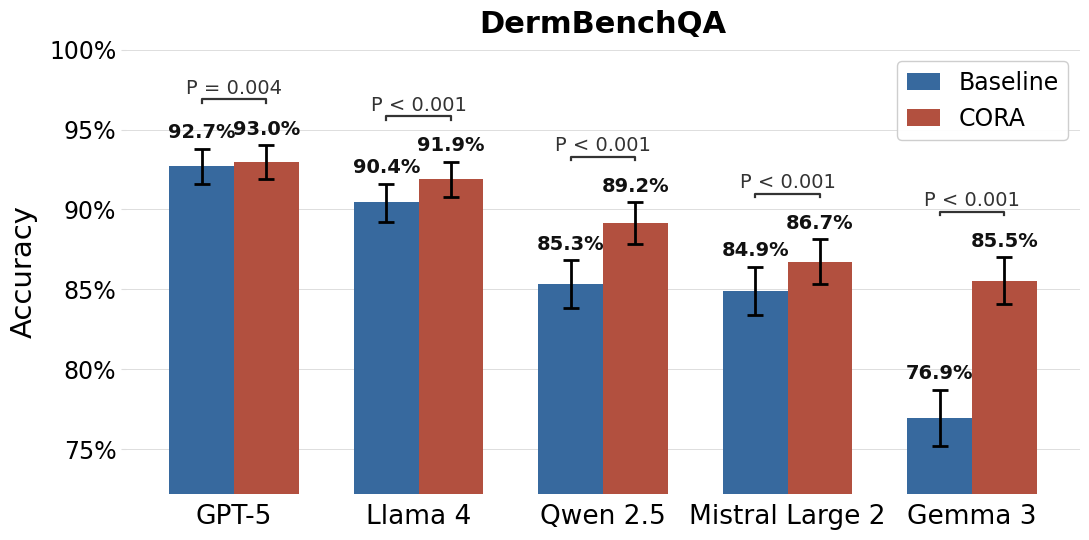

In [17]:
from scipy.stats import norm, binom

# ------------------------------------------------------------------
#  Which paired test to run and display.
#    "noninferiority" -> RAG is not meaningfully worse than baseline (margin below)
#    "superiority"    -> RAG differs from baseline (two-sided McNemar)
#  See paired_p() / test_caption() below. Both are paired (McNemar);
#  non-inferiority is one-sided, superiority is two-sided.
# ------------------------------------------------------------------
TEST_TYPE = "noninferiority"   # "noninferiority" or "superiority"

NI_MARGIN = 0.01  # non-inferiority margin: RAG must not be worse than baseline by more than x pp

def noninferiority_p(b_correct, r_correct, margin=NI_MARGIN):
    """One-sided non-inferiority test for paired binary outcomes (McNemar-based).

    H0: p_RAG - p_baseline <= -margin  (RAG is inferior)
    H1: p_RAG - p_baseline >  -margin  (RAG is non-inferior)

    Returns the one-sided p-value; conclude non-inferiority if p < 0.05.
    """
    n = len(b_correct)
    if n == 0:
        return 1.0
    b = int(((b_correct == 1) & (r_correct == 0)).sum())  # baseline only correct
    c = int(((b_correct == 0) & (r_correct == 1)).sum())  # rag only correct
    d = (c - b) / n                                        # estimated p_RAG - p_baseline
    var = (b + c - (c - b) ** 2 / n) / n ** 2
    if var <= 0:
        return 0.0 if d > -margin else 1.0
    z = (d + margin) / np.sqrt(var)
    return float(norm.sf(z))  # one-sided p-value

def superiority_p(b_correct, r_correct):
    """Two-sided exact McNemar test for paired binary outcomes.

    H0: p_RAG == p_baseline   (no difference)
    H1: p_RAG != p_baseline   (RAG differs from baseline, in either direction)

    Only the discordant pairs carry information: under H0 the number of pairs
    where RAG alone is correct is Binomial(n_disc, 0.5). We use the exact
    binomial two-sided p-value (double the smaller tail, robust when discordant
    counts are small) rather than the normal approximation. Conclude a
    significant difference if p < 0.05.
    """
    b = int(((b_correct == 1) & (r_correct == 0)).sum())  # baseline only correct
    c = int(((b_correct == 0) & (r_correct == 1)).sum())  # rag only correct
    n_disc = b + c
    if n_disc == 0:
        return 1.0
    lo = binom.cdf(c, n_disc, 0.5)      # P(X <= c)
    hi = binom.sf(c - 1, n_disc, 0.5)   # P(X >= c)
    return float(min(1.0, 2.0 * min(lo, hi)))  # two-sided: double the smaller tail

def paired_p(b_correct, r_correct, test_type=None):
    """Dispatch to the selected paired test. Set TEST_TYPE at the top of this cell."""
    test_type = test_type or TEST_TYPE
    if test_type == "noninferiority":
        return noninferiority_p(b_correct, r_correct)
    if test_type == "superiority":
        return superiority_p(b_correct, r_correct)
    raise ValueError(f"Unknown TEST_TYPE: {test_type!r} (use 'noninferiority' or 'superiority')")

def test_caption():
    """Human-readable description of the active test, for figure footnotes."""
    if TEST_TYPE == "noninferiority":
        return f"One-sided non-inferiority test (McNemar, margin={NI_MARGIN * 100:.0f} pp)"
    return "Two-sided McNemar test (exact)"

def holm_bonferroni(pvals):
    """Holm-Bonferroni step-down adjusted p-values, returned in the input order.

    Controls the family-wise error rate like plain Bonferroni but is uniformly
    more powerful (less conservative): only the smallest raw p is multiplied by
    the full m, the next by m-1, and so on. Values are clipped to 1 and made
    monotone along the sorted order, so a test never adjusts below one with a
    smaller raw p. Compare each adjusted p to the usual 0.05.
    """
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)               # indices of p sorted ascending
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):  # rank = 0..m-1
        running = max(running, (m - rank) * p[idx])  # enforce monotonicity
        adj[idx] = min(running, 1.0)
    return adj

def fmt_pval(p):
    if p < 0.001:
        return "P < 0.001"
    else:
        return f"P = {p:.3f}"

def add_sig_bracket(ax, x_left, x_right, y_bottom, p_val, h, fontsize=14):
    """Draw a significance bracket. h (tick height) and text offset scale with the axis."""
    y_bar = y_bottom + h * 0.4
    ax.plot([x_left, x_left, x_right, x_right],
            [y_bottom, y_bar, y_bar, y_bottom], lw=1.6, c="#333333", clip_on=False)
    ax.text((x_left + x_right) / 2, y_bar + h * 0.15,
            fmt_pval(p_val), ha="center", va="bottom",
            fontsize=fontsize, color="#333333")


def plot_accuracy(dfs, models_config, save_path=None, y_top=1.0, title=None, order=None):
    """Grouped baseline-vs-RAG accuracy bar chart with 95% CIs and per-model p-values.

    dfs: dict keyed by (model, "baseline"|"rag") -> DataFrame[question_id, is_correct].
    Each model is matched on the question_ids common to its own baseline and RAG runs.
    Raw per-model p-values come from paired_p() (whichever TEST_TYPE is active) and are
    then Holm-Bonferroni adjusted across models. Vertical offsets (value labels,
    brackets) scale with the y-axis range so the layout holds up whether the data spans
    a narrow band (medqa) or a wide one (pubmed).
    """
    models = [m for m in models_config
              if (m, "baseline") in dfs and (m, "rag") in dfs]
    width = 0.35

    results = {}
    for model in models:
        base_df = dfs[(model, "baseline")].set_index("question_id").sort_index()
        rag_df  = dfs[(model, "rag")].set_index("question_id").sort_index()
        common  = base_df.index.intersection(rag_df.index)
        bc = base_df.loc[common, "is_correct"].values.astype(float)
        rc = rag_df.loc[common, "is_correct"].values.astype(float)
        n  = len(bc)

        bm, blo, bhi = bootstrap_ci(bc)
        rm, rlo, rhi = bootstrap_ci(rc)
        results[model] = dict(baseline=bm, baseline_lo=blo, baseline_hi=bhi,
                              rag=rm,      rag_lo=rlo,      rag_hi=rhi,
                              p_raw=paired_p(bc, rc), n=n)

    # Holm-Bonferroni across the models tested (FWER control, less conservative than Bonferroni).
    for model, p_val in zip(models, holm_bonferroni([results[m]["p_raw"] for m in models])):
        results[model]["p_value"] = p_val
        r = results[model]
        print(f"  {model} (n={r['n']:,}): baseline={r['baseline']:.3f}  "
              f"rag={r['rag']:.3f}  {fmt_pval(p_val)}")

    # Explicit `order` (list of model keys) wins, so a second dataset can reuse
    # another plot's ordering; otherwise fall back to best-RAG-first.
    if order is not None:
        models = [m for m in order if m in results]
    else:
        models = sorted(models, key=lambda m: results[m]["rag"], reverse=True)
    x = np.arange(len(models))

    b_vals = [results[m]["baseline"]     for m in models]
    r_vals = [results[m]["rag"]          for m in models]
    b_err  = [[results[m]["baseline_lo"] for m in models],
              [results[m]["baseline_hi"] for m in models]]
    r_err  = [[results[m]["rag_lo"]      for m in models],
              [results[m]["rag_hi"]      for m in models]]

    err_kw = dict(elinewidth=2.0, capsize=6, capthick=2.0, ecolor="black")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    bars1 = ax.bar(x - width / 2, b_vals, width, yerr=b_err, error_kw=err_kw,
                   label="Baseline", color=BASELINE_COLOR, edgecolor="none", zorder=3)
    bars2 = ax.bar(x + width / 2, r_vals, width, yerr=r_err, error_kw=err_kw,
                   label="CORA", color=RAG_COLOR, edgecolor="none", zorder=3)

    # Set y-limits first so all vertical offsets can be expressed as a fraction of the range.
    all_down = [v - e for v, e in zip(b_vals + r_vals, b_err[0] + r_err[0])]
    y_bottom = max(0, min(all_down) - 0.03)
    ax.set_ylim(y_bottom, y_top)
    yr = y_top - y_bottom  # visible data range, in axis units

    label_gap   = 0.015 * yr  # value label sits this far above its error bar
    bracket_gap = 0.095 * yr  # bracket clears the (fixed-height) value labels
    bracket_h   = 0.020 * yr  # bracket tick height

    for bar, hi in zip(bars1, b_err[1]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + hi + label_gap,
                f"{bar.get_height() * 100:.1f}%", ha="center", va="bottom",
                fontsize=14, fontweight="bold", color="#111111")
    for bar, hi in zip(bars2, r_err[1]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + hi + label_gap,
                f"{bar.get_height() * 100:.1f}%", ha="center", va="bottom",
                fontsize=14, fontweight="bold", color="#111111")

    for i, model in enumerate(models):
        p_val = results[model]["p_value"]
        top_b = b_vals[i] + b_err[1][i]
        top_r = r_vals[i] + r_err[1][i]
        bracket_y = max(top_b, top_r) + bracket_gap
        add_sig_bracket(ax, i - width / 2, i + width / 2, bracket_y, p_val, h=bracket_h)

    tick_labels = [models_config[m] for m in models]
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=19)
    ax.set_ylabel("Accuracy", fontsize=21, labelpad=8)
    if title:
        ax.set_title(title, fontsize=22, fontweight="bold", loc="center", pad=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.grid(True, linestyle="-", linewidth=0.7, color="#DDDDDD", zorder=0)
    #ax.yaxis
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.tick_params(axis="x", bottom=False, color="#DDDDDD")
    ax.tick_params(axis="y", labelsize=17, color="#DDDDDD")
    ax.legend(fontsize=17, framealpha=0.95, edgecolor="#CCCCCC",
              loc="upper right", handlelength=1.4)

    caption_kw = dict(ha="center", va="top", fontsize=12, style="italic", color="#777777")
    n_vals = sorted({results[m]["n"] for m in models})
    n_txt = f"n = {n_vals[0]:,} matched questions per model" if len(n_vals) == 1 else "matched question set per model"
    #fig.text(0.5, -0.05,
    #         f"{n_txt}.  {test_caption()}. P-values Holm-Bonferroni-corrected (m={len(models)}).",
    #         **caption_kw)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return results


# MedQA test set
print("[medqa]")
medqa_results = plot_accuracy(
    dfs_by_dataset["medqa"],
    models_config,
    save_path="../plots/accuracy_benchmarks/accuracy_comparison_medqa.png",
    title="DermBenchQA",
)

[pubmed]
  gpt5 (n=437): baseline=0.771  rag=0.805  P = 0.005
  llama4 (n=437): baseline=0.513  rag=0.622  P < 0.001
  mistrallarge2 (n=437): baseline=0.551  rag=0.650  P < 0.001
  qwen2.5 (n=437): baseline=0.465  rag=0.645  P < 0.001
  gemma3 (n=437): baseline=0.375  rag=0.602  P < 0.001


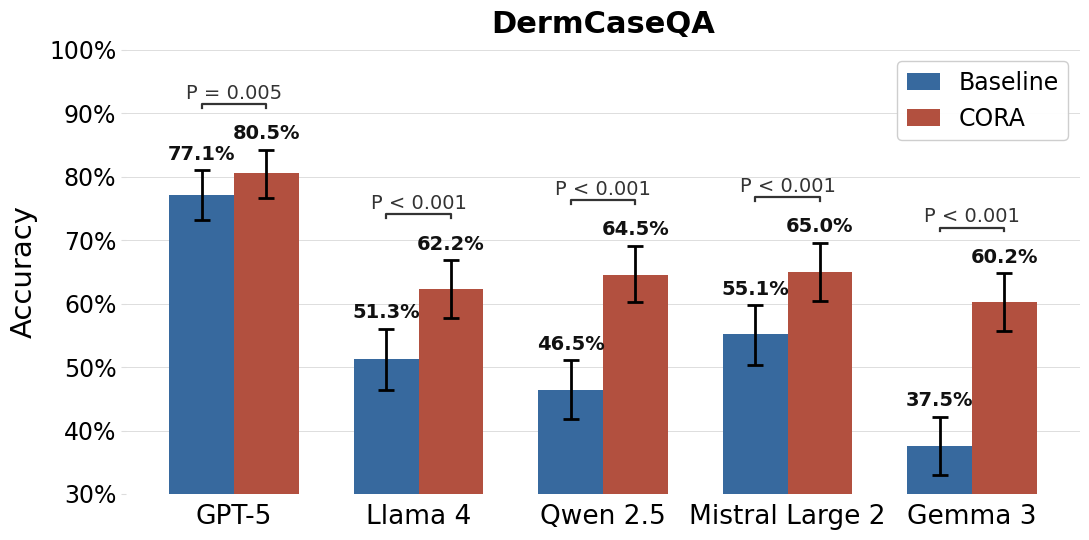

In [18]:
# PubMed test set
# Reuse the MedQA model order (best-RAG-first there) so both plots line up.
medqa_order = sorted(medqa_results, key=lambda m: medqa_results[m]["rag"], reverse=True)
print("[pubmed]")
pubmed_results = plot_accuracy(
    dfs_by_dataset["pubmed"],
    models_config,
    save_path="../plots/accuracy_benchmarks/accuracy_comparison_pubmed.png",
    title="DermCaseQA",
    order=medqa_order,
)

In [19]:
# --- Horizontal bar version (does not touch the vertical plot_accuracy above) ---

def add_sig_bracket_h(ax, y_lo, y_hi, x_left, p_val, w, fontsize=14):
    """Draw a rightward significance bracket connecting two horizontal bars.

    y_lo/y_hi are the vertical centers of the two bars; x_left is where the
    bracket starts (just right of the longer bar). Legs point right to x_bar,
    the p-value label sits to the right of the spine.
    """
    x_bar = x_left + w * 0.4
    ax.plot([x_left, x_bar, x_bar, x_left],
            [y_lo, y_lo, y_hi, y_hi], lw=1.6, c="#333333", clip_on=False)
    ax.text(x_bar + w * 0.25, (y_lo + y_hi) / 2,
            fmt_pval(p_val), ha="left", va="center",
            fontsize=fontsize, color="#333333")


def plot_accuracy_h(dfs, models_config, save_path=None, title=None, order=None):
    """Horizontal baseline-vs-RAG accuracy chart with 95% CIs and per-model p-values.

    Same statistics and matching logic as plot_accuracy, transposed to horizontal
    bars. Raw per-model p-values come from paired_p() (whichever TEST_TYPE is active)
    and are then Holm-Bonferroni adjusted across models. Value labels sit to the right
    of each bar; significance brackets and p-values sit in a column right of each model
    group. Horizontal offsets scale with the data span so the layout holds for both
    narrow (medqa) and wide (pubmed) ranges.
    """
    models = [m for m in models_config
              if (m, "baseline") in dfs and (m, "rag") in dfs]
    height = 0.35

    results = {}
    for model in models:
        base_df = dfs[(model, "baseline")].set_index("question_id").sort_index()
        rag_df  = dfs[(model, "rag")].set_index("question_id").sort_index()
        common  = base_df.index.intersection(rag_df.index)
        bc = base_df.loc[common, "is_correct"].values.astype(float)
        rc = rag_df.loc[common, "is_correct"].values.astype(float)
        n  = len(bc)

        bm, blo, bhi = bootstrap_ci(bc)
        rm, rlo, rhi = bootstrap_ci(rc)
        results[model] = dict(baseline=bm, baseline_lo=blo, baseline_hi=bhi,
                              rag=rm,      rag_lo=rlo,      rag_hi=rhi,
                              p_raw=paired_p(bc, rc), n=n)

    # Holm-Bonferroni across the models tested (FWER control, less conservative than Bonferroni).
    for model, p_val in zip(models, holm_bonferroni([results[m]["p_raw"] for m in models])):
        results[model]["p_value"] = p_val
        r = results[model]
        print(f"  {model} (n={r['n']:,}): baseline={r['baseline']:.3f}  "
              f"rag={r['rag']:.3f}  {fmt_pval(p_val)}")

    # Best RAG accuracy on top (y-axis inverted below).
    # Explicit `order` (list of model keys) wins, so a second dataset can reuse
    # another plot's ordering; otherwise fall back to best-RAG-first.
    if order is not None:
        models = [m for m in order if m in results]
    else:
        models = sorted(models, key=lambda m: results[m]["rag"], reverse=True)
    y = np.arange(len(models))

    b_vals = [results[m]["baseline"]     for m in models]
    r_vals = [results[m]["rag"]          for m in models]
    b_err  = [[results[m]["baseline_lo"] for m in models],
              [results[m]["baseline_hi"] for m in models]]
    r_err  = [[results[m]["rag_lo"]      for m in models],
              [results[m]["rag_hi"]      for m in models]]

    err_kw = dict(elinewidth=2.0, capsize=6, capthick=2.0, ecolor="black")

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Baseline on top, RAG below within each group (reads top->bottom after invert).
    bars1 = ax.barh(y - height / 2, b_vals, height, xerr=b_err, error_kw=err_kw,
                    label="Baseline", color=BASELINE_COLOR, edgecolor="none", zorder=3)
    bars2 = ax.barh(y + height / 2, r_vals, height, xerr=r_err, error_kw=err_kw,
                    label="Agentic RAG", color=RAG_COLOR, edgecolor="none", zorder=3)

    # Establish the horizontal span, then express all offsets as a fraction of it.
    all_down = [v - e for v, e in zip(b_vals + r_vals, b_err[0] + r_err[0])]
    all_up   = [v + e for v, e in zip(b_vals + r_vals, b_err[1] + r_err[1])]
    x_left  = max(0, min(all_down) - 0.03)
    data_max = max(all_up)
    span = data_max - x_left
    x_right = data_max + 0.55 * span  # room for value labels, brackets and p-values
    ax.set_xlim(x_left, x_right)

    label_gap   = 0.02 * span  # value label sits this far right of its error bar
    bracket_gap = 0.20 * span  # bracket clears the value labels
    bracket_w   = 0.05 * span  # bracket leg length

    for bar, hi in zip(bars1, b_err[1]):
        ax.text(bar.get_width() + hi + label_gap, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width() * 100:.1f}%", ha="left", va="center",
                fontsize=14, fontweight="bold", color="#111111")
    for bar, hi in zip(bars2, r_err[1]):
        ax.text(bar.get_width() + hi + label_gap, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width() * 100:.1f}%", ha="left", va="center",
                fontsize=14, fontweight="bold", color="#111111")

    for i, model in enumerate(models):
        p_val = results[model]["p_value"]
        right_b = b_vals[i] + b_err[1][i]
        right_r = r_vals[i] + r_err[1][i]
        bracket_x = max(right_b, right_r) + bracket_gap
        add_sig_bracket_h(ax, i - height / 2, i + height / 2, bracket_x, p_val, w=bracket_w)

    tick_labels = [models_config[m] for m in models]
    ax.set_yticks(y)
    ax.set_yticklabels(tick_labels, fontsize=19)
    ax.invert_yaxis()  # best model on top
    ax.set_xlabel("Accuracy", fontsize=21, labelpad=8)
    if title:
        ax.set_title(title, fontsize=22, fontweight="bold", loc="center", pad=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color="#DDDDDD", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.tick_params(axis="y", left=False, color="#DDDDDD")
    ax.tick_params(axis="x", labelsize=17, color="#DDDDDD")
    ax.legend(fontsize=17, framealpha=0.95, edgecolor="#CCCCCC",
              loc="lower right", handlelength=1.4)

    caption_kw = dict(ha="center", va="top", fontsize=12, style="italic", color="#777777")
    n_vals = sorted({results[m]["n"] for m in models})
    n_txt = f"n = {n_vals[0]:,} matched questions per model" if len(n_vals) == 1 else "matched question set per model"
    fig.text(0.5, -0.05,
             f"{n_txt}.  {test_caption()}. P-values Holm-Bonferroni-corrected (m={len(models)}).",
             **caption_kw)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return results

[medqa]
  gpt5 (n=2,207): baseline=0.927  rag=0.930  P = 0.004
  llama4 (n=2,207): baseline=0.904  rag=0.919  P < 0.001
  mistrallarge2 (n=2,207): baseline=0.849  rag=0.867  P < 0.001
  qwen2.5 (n=2,207): baseline=0.853  rag=0.892  P < 0.001
  gemma3 (n=2,207): baseline=0.769  rag=0.855  P < 0.001


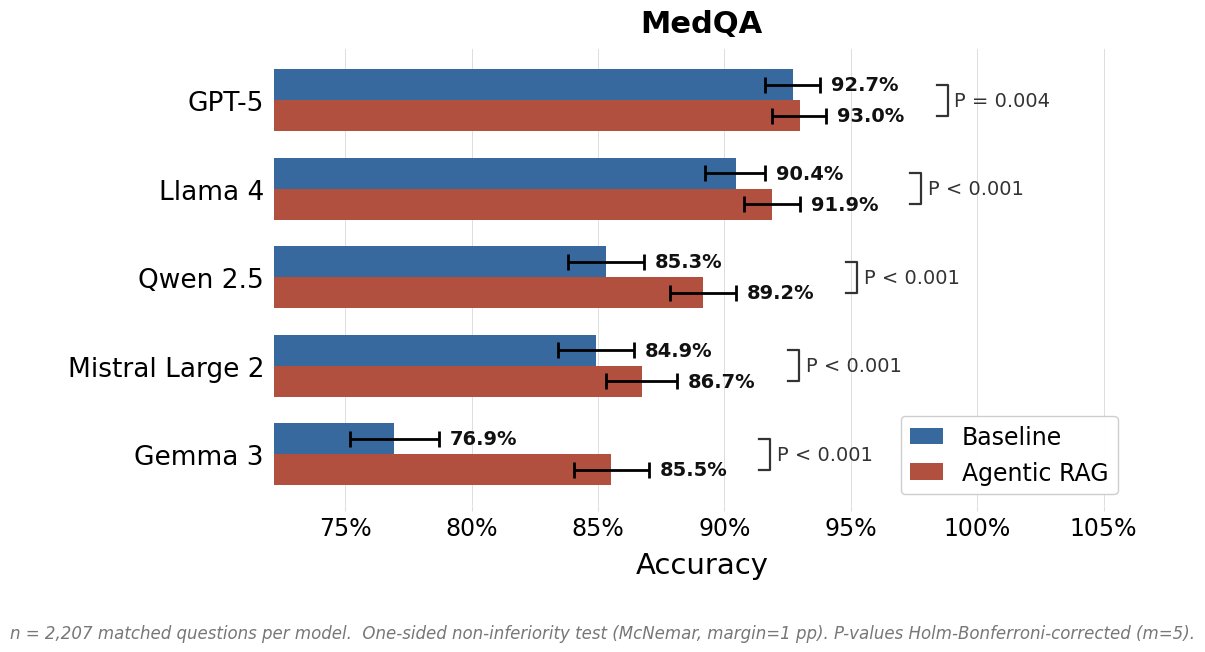

In [20]:
# MedQA test set (horizontal)
print("[medqa]")
medqa_results_h = plot_accuracy_h(
    dfs_by_dataset["medqa"],
    models_config,
    save_path="../plots/accuracy_benchmarks/accuracy_comparison_medqa_horizontal.png",
    title="MedQA",
)

[pubmed]
  gpt5 (n=437): baseline=0.771  rag=0.805  P = 0.005
  llama4 (n=437): baseline=0.513  rag=0.622  P < 0.001
  mistrallarge2 (n=437): baseline=0.551  rag=0.650  P < 0.001
  qwen2.5 (n=437): baseline=0.465  rag=0.645  P < 0.001
  gemma3 (n=437): baseline=0.375  rag=0.602  P < 0.001


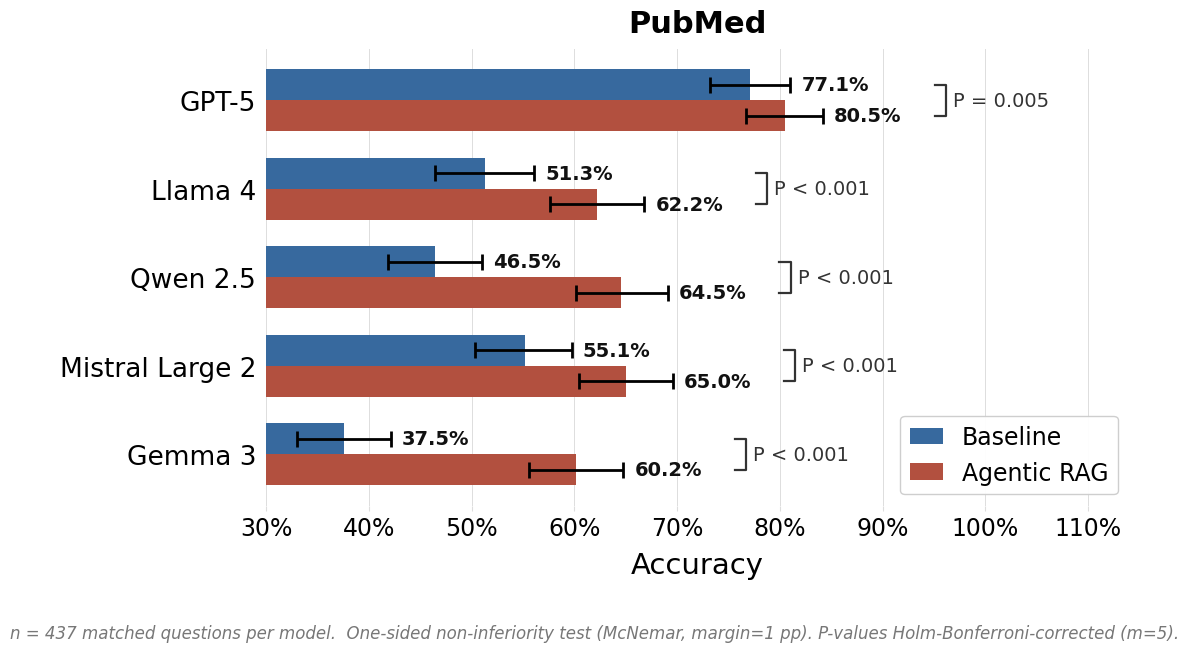

In [21]:
# PubMed test set (horizontal)
# Reuse the MedQA model order (best-RAG-first there) so both plots line up.
medqa_order_h = sorted(medqa_results_h, key=lambda m: medqa_results_h[m]["rag"], reverse=True)
print("[pubmed]")
pubmed_results_h = plot_accuracy_h(
    dfs_by_dataset["pubmed"],
    models_config,
    save_path="../plots/accuracy_benchmarks/accuracy_comparison_pubmed_horizontal.png",
    title="PubMed",
    order=medqa_order_h,
)

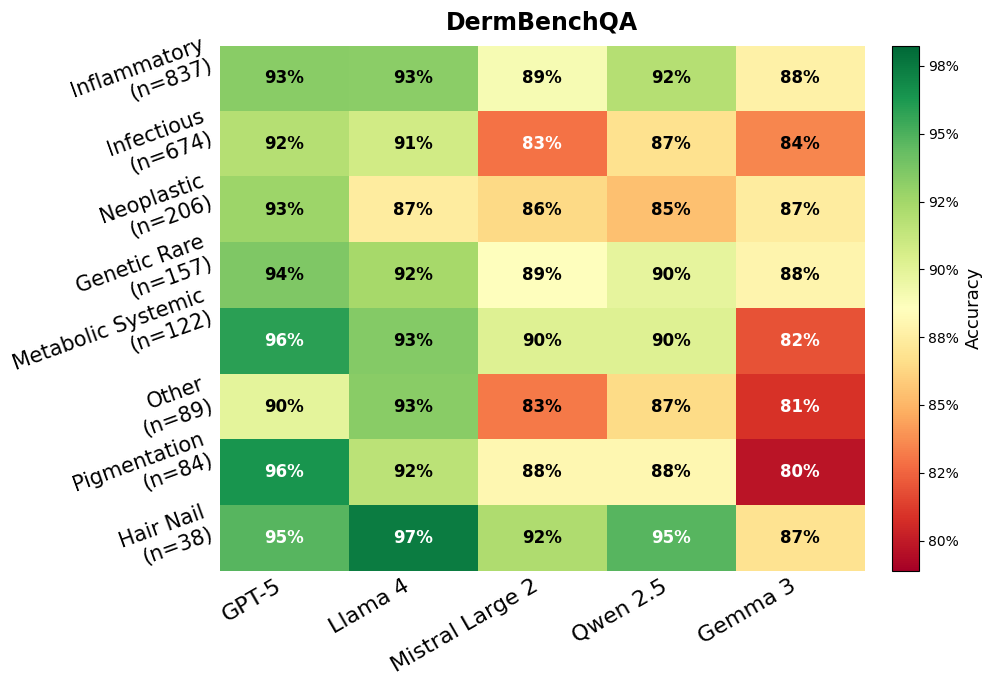

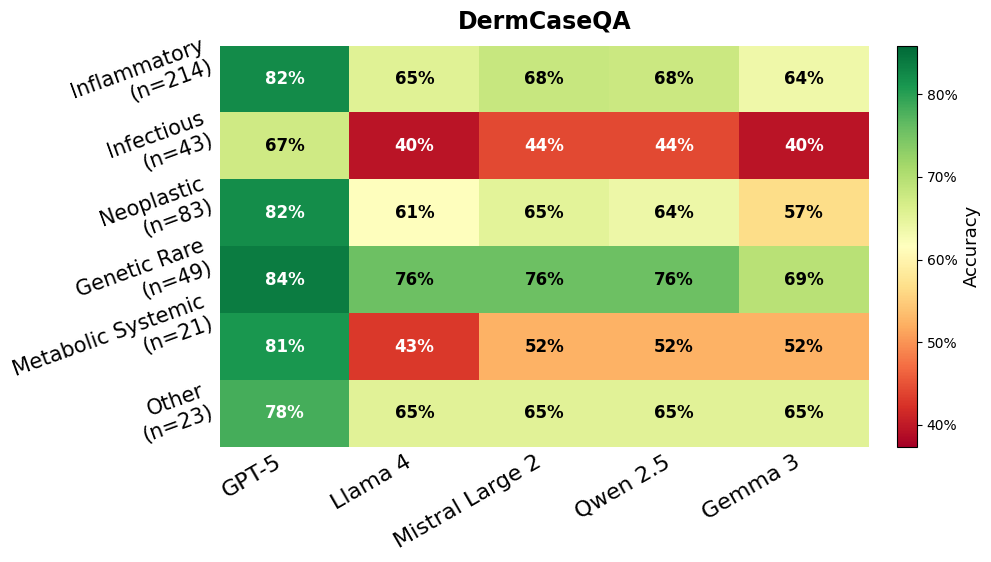

In [22]:
# =========================================================
#  Accuracy by disease category, per model  (companion / absolute view)
#  Category files key on question_id (per dataset) -- same key as the results.
# =========================================================
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

CATEGORY_FILES = {
    "medqa":  f"{RESULTS_DIR}/question_categories_cleaned.csv",
    "pubmed": f"{RESULTS_DIR}/question_categories_pubmed_cleaned.csv",
}
LOW_N = 20  # cells with fewer questions than this are still shown, but flagged unreliable
MIN_N = 10  # categories with fewer questions than this (in a dataset) are dropped entirely
DATASET_TITLES = {"medqa": "DermBenchQA", "pubmed": "DermCaseQA"}


def _category_order(datasets=DATASETS):
    """Fixed category row order shared by every dataset, most-common first.

    Ordered by total question count across all datasets so the MedQA and PubMed
    heatmaps have identical rows in identical positions and read side by side.
    """
    counts = None
    for ds in datasets:
        c = pd.read_csv(CATEGORY_FILES[ds])["disease_category"].value_counts()
        counts = c if counts is None else counts.add(c, fill_value=0)
    return list(counts.sort_values(ascending=False).index)


CATEGORY_ORDER = _category_order()


def _text_color(cmap, norm_val):
    """Black or white label, whichever contrasts with the cell colour."""
    r, g, b, _ = cmap(norm_val)
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if lum > 0.6 else "white"


def _delta_norm(values, pad_frac=0.06):
    """Symmetric diverging norm: vmin = -vmax, fit just past the largest |delta|.

    Symmetric limits make equal +/- magnitudes read as equal colour intensity;
    the span hugs the data (pad_frac past the largest |delta|), 0 stays white.
    """
    m = float(np.nanmax(np.abs(values)))            # largest |delta| either way
    lim = max(m * (1 + pad_frac), 1e-9)             # a little past the extreme
    return mcolors.Normalize(vmin=-lim, vmax=lim)   # 0 auto-centres (white)


def _pp(v):
    """Signed pp label; anything that rounds to 0 shows a plain '0' (no +/-)."""
    s = f"{v:+.0f}"
    return "0" if s in ("+0", "-0") else s


def _flag_low_n_rows(ax, n, ncols):
    """Hatch every row whose category has < LOW_N questions to mark it as noisy."""
    for i, cat in enumerate(n.index):
        if n[cat] < LOW_N:
            ax.add_patch(mpatches.Rectangle(
                (-0.5, i - 0.5), ncols, 1, fill=False,
                hatch="////", edgecolor="#555555", linewidth=0, zorder=4))


def _ylabels(n):
    """Row labels 'Category (n=…)', asterisked when below the reliability threshold."""
    return [f"{c}\n(n={n[c]:,}){' *' if n[c] < LOW_N else ''}" for c in n.index]


def accuracy_by_category(dataset, condition="rag"):
    """Return (accuracy_df[category x model], n_per_category) for one condition.

    condition: "rag" or "baseline". Accuracy is the mean of is_correct over the
    questions each model actually answered in that condition, joined to the
    question's disease_category. Rows follow the shared CATEGORY_ORDER so datasets
    align; no category is dropped (small-n rows are flagged at plot time instead).
    """
    cats = pd.read_csv(CATEGORY_FILES[dataset])[["question_id", "disease_category"]]
    frames = []
    for model in models_by_dataset[dataset]:
        m = dfs_by_dataset[dataset][(model, condition)].merge(cats, on="question_id")
        m["model"] = models_config[model]
        frames.append(m)
    long = pd.concat(frames, ignore_index=True)

    acc = long.groupby(["disease_category", "model"])["is_correct"].mean().unstack("model")
    n   = long.groupby("disease_category")["question_id"].nunique()

    acc = acc[[models_config[m] for m in models_by_dataset[dataset]]]     # column order
    order = [c for c in CATEGORY_ORDER if c in acc.index and n.get(c, 0) >= MIN_N]  # drop tiny
    return acc.loc[order], n.loc[order]


def plot_category_heatmap(dataset, condition="rag", save_path=None):
    acc, n = accuracy_by_category(dataset, condition)
    cmap = plt.get_cmap("RdYlGn")

    fig, ax = plt.subplots(figsize=(1.3 * len(acc.columns) + 3.5, 0.62 * len(acc) + 2))
    fig.patch.set_facecolor("white")
    lo, hi = float(np.nanmin(acc.values)), float(np.nanmax(acc.values))
    pad = 0.05 * max(hi - lo, 1e-9)   # fit just past the min/max
    vmin, vmax = max(0.0, lo - pad), min(1.0, hi + pad)
    im = ax.imshow(acc.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(range(len(acc.columns)))
    ax.set_xticklabels(acc.columns, rotation=30, ha="right", fontsize=16)
    ax.set_yticks(range(len(acc.index)))
    ax.set_yticklabels(_ylabels(n), fontsize=15, rotation=20, va="center")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    for i in range(acc.shape[0]):
        for j in range(acc.shape[1]):
            v = acc.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v * 100:.0f}%", ha="center", va="center",
                        fontsize=12, fontweight="bold", color=_text_color(cmap, (v - vmin) / (vmax - vmin)))

    _flag_low_n_rows(ax, n, acc.shape[1])

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Accuracy", fontsize=13)
    cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    cond_label = "Agentic RAG" if condition == "rag" else "Baseline"
    ax.set_title(DATASET_TITLES[dataset],
                 fontsize=17, fontweight="bold", pad=12)
    if (n < LOW_N).any():
        fig.text(0.5, -0.03, f"* hatched: n < {LOW_N}; per-category rate is unreliable.",
                 ha="center", va="top", fontsize=11, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return acc


for ds in DATASETS:
    plot_category_heatmap(
        ds, condition="rag",
        save_path=f"../plots/accuracy_benchmarks/accuracy_by_category_{ds}_rag.png",
    )


[dumbbell] medqa / llama4


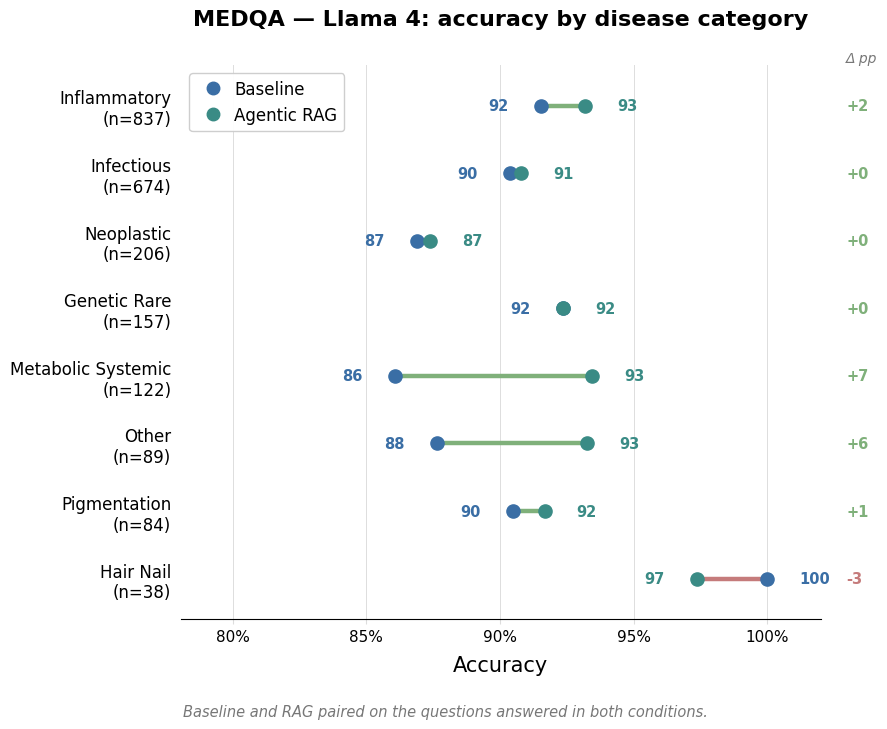

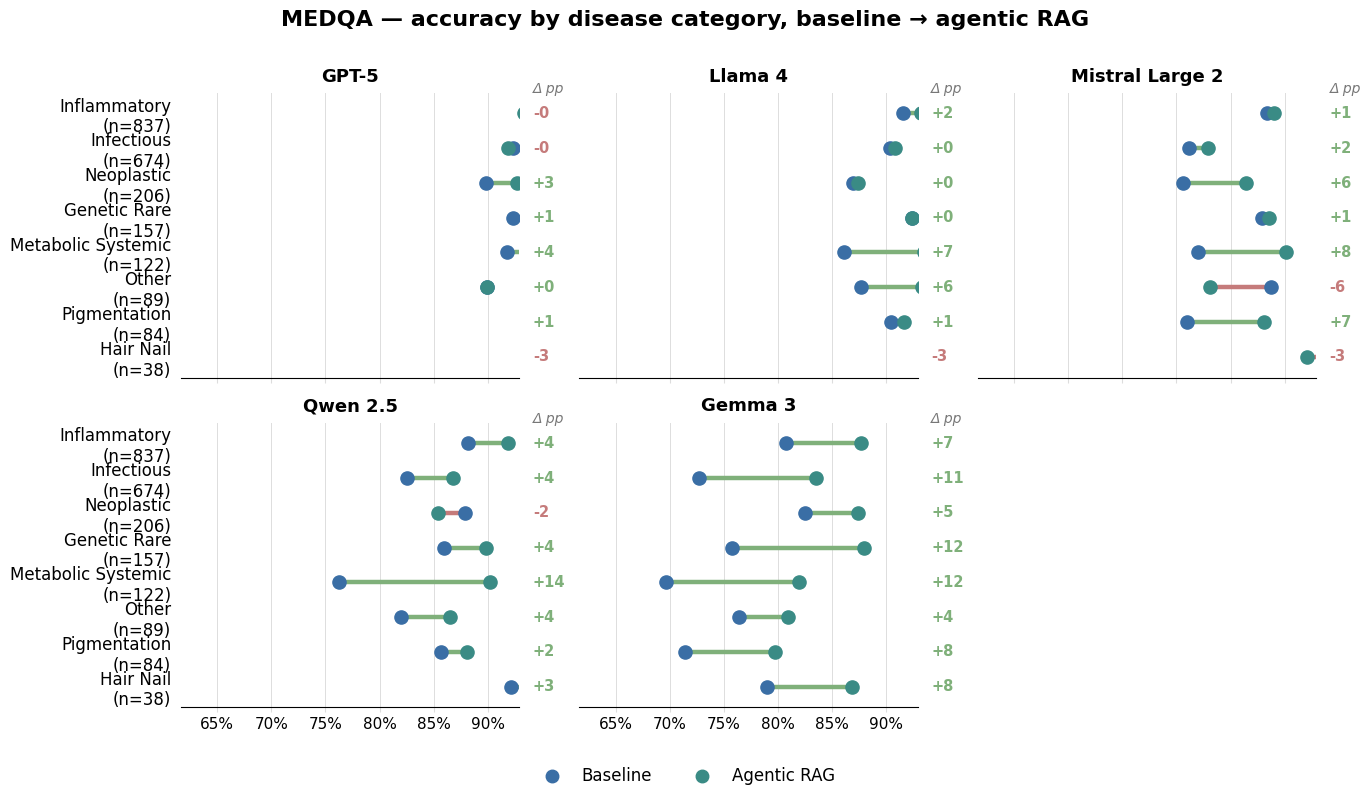

In [23]:
# =========================================================
#  Dumbbell: baseline -> agentic RAG accuracy by disease category
#  Companion to the category heatmaps. Each category's two dots are computed on
#  the question_ids that model answered in BOTH conditions (same pairing as
#  delta_by_category), so baseline and RAG sit on an identical question set.
#  Categories with n < MIN_N are omitted: on a dumbbell a 1-3 sample category
#  produces a huge, misleading bar (unlike the heatmap, where we hatch instead).
# =========================================================
import os

# --- pick the model shown in the single-model dumbbell here ---
DUMBBELL_DATASET = "medqa"   # "medqa" or "pubmed" (pubmed = contamination-free set)
DUMBBELL_MODEL   = "llama4"     # any key in models_by_dataset[DUMBBELL_DATASET]
MIN_N            = LOW_N      # drop categories with fewer paired questions than this

BASE_COLOR = "#3A6EA5"        # matches the baseline bars elsewhere in this notebook
RAG_COLOR  = "#3A8B85"        # matches the agentic-RAG bars
UP_COLOR   = "#7FB07A"        # connector when RAG improves on baseline
DOWN_COLOR = "#C57B7B"        # connector when RAG is worse


def _dumbbell_ylabels(n):
    """Row labels with the count on a SECOND line, so the y-axis stays narrow.

    Dumbbell-specific (heatmaps keep the single-line _ylabels). Still asterisks
    below-threshold rows in case a caller lowers min_n.
    """
    return [f"{c}\n(n={n[c]:,}){' *' if n[c] < LOW_N else ''}" for c in n.index]


def paired_accuracy_by_category(dataset, model, min_n=MIN_N):
    """Per-category baseline & RAG accuracy for one model, paired on shared question_ids.

    Returns a DataFrame indexed by disease_category (in shared CATEGORY_ORDER) with
    columns [baseline, rag, delta_pp, n]; categories with n < min_n are dropped.
    Same paired construction as delta_by_category.
    """
    cats = pd.read_csv(CATEGORY_FILES[dataset])[["question_id", "disease_category"]]
    b = dfs_by_dataset[dataset][(model, "baseline")].set_index("question_id")["is_correct"]
    r = dfs_by_dataset[dataset][(model, "rag")].set_index("question_id")["is_correct"]
    shared = b.index.intersection(r.index)
    d = (pd.DataFrame({"baseline": b.loc[shared], "rag": r.loc[shared]})
           .reset_index().merge(cats, on="question_id"))
    g = d.groupby("disease_category")
    out = pd.DataFrame({"baseline": g["baseline"].mean(),
                        "rag":      g["rag"].mean(),
                        "n":        g.size()})
    out["delta_pp"] = (out["rag"] - out["baseline"]) * 100
    out = out[out["n"] >= min_n]
    order = [c for c in CATEGORY_ORDER if c in out.index]
    return out.loc[order]


def _dumbbell_on_ax(ax, tbl, show_values=True, show_ylabels=True, show_delta=True):
    """Draw one baseline->RAG dumbbell panel from a paired-accuracy table `tbl`.

    First category sits at the top. Endpoint % labels (show_values) sit on the
    outer side of each pair; the RAG-baseline delta (show_delta) sits in a right
    gutter drawn in axes-fraction x so it never distorts the percent axis.
    """
    y = np.arange(len(tbl))[::-1]
    for yi, (_, row) in zip(y, tbl.iterrows()):
        up = row["rag"] >= row["baseline"]
        ax.plot([row["baseline"], row["rag"]], [yi, yi],
                color=(UP_COLOR if up else DOWN_COLOR), lw=3.2, zorder=2,
                solid_capstyle="round")
    ax.scatter(tbl["baseline"], y, s=90, color=BASE_COLOR, zorder=3, label="Baseline")
    ax.scatter(tbl["rag"],      y, s=90, color=RAG_COLOR,  zorder=3, label="Agentic RAG")

    if show_values:
        dx = 0.012
        for yi, (_, row) in zip(y, tbl.iterrows()):
            b, r = row["baseline"], row["rag"]
            b_side, r_side = (("right", "left") if b <= r else ("left", "right"))
            ax.text(b + (-dx if b_side == "right" else dx), yi, f"{b*100:.0f}",
                    ha=b_side, va="center", fontsize=10.5, color=BASE_COLOR, fontweight="bold")
            ax.text(r + (dx if r_side == "left" else -dx), yi, f"{r*100:.0f}",
                    ha=r_side, va="center", fontsize=10.5, color=RAG_COLOR, fontweight="bold")

    if show_delta:
        trans = ax.get_yaxis_transform()  # x in axes fraction, y in data coords
        for yi, d in zip(y, tbl["delta_pp"]):
            ax.text(1.04, yi, f"{d:+.0f}", transform=trans, ha="left", va="center",
                    fontsize=10.5, fontweight="bold",
                    color=(UP_COLOR if d >= 0 else DOWN_COLOR))
        ax.text(1.04, len(tbl) - 0.3, "Δ pp", transform=trans, ha="left", va="center",
                fontsize=10, style="italic", color="#777777")

    ax.set_yticks(y)
    ax.set_yticklabels(_dumbbell_ylabels(tbl["n"]) if show_ylabels else [], fontsize=12)
    lo = max(0.0, float(min(tbl["baseline"].min(), tbl["rag"].min())) - 0.08)
    hi = min(1.02, float(max(tbl["baseline"].max(), tbl["rag"].max())) + 0.05)
    ax.set_xlim(lo, hi)
    ax.set_ylim(-0.6, len(tbl) - 0.4)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color="#DDDDDD", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", left=False)
    ax.tick_params(axis="x", labelsize=11, color="#DDDDDD")


def _dumbbell_legend_handles():
    return [plt.Line2D([], [], marker="o", ls="", ms=9, color=BASE_COLOR, label="Baseline"),
            plt.Line2D([], [], marker="o", ls="", ms=9, color=RAG_COLOR,  label="Agentic RAG")]


def plot_category_dumbbell(dataset, model, min_n=MIN_N, save_path=None):
    """Single-model baseline->RAG accuracy dumbbell by disease category (main-figure form)."""
    tbl_full = paired_accuracy_by_category(dataset, model, min_n=0)
    tbl = tbl_full[tbl_full["n"] >= min_n]
    dropped = [f"{c} (n={int(tbl_full.loc[c, 'n'])})"
               for c in tbl_full.index if tbl_full.loc[c, "n"] < min_n]

    fig, ax = plt.subplots(figsize=(9, 0.62 * len(tbl) + 2))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    _dumbbell_on_ax(ax, tbl, show_values=True, show_ylabels=True, show_delta=True)
    ax.set_xlabel("Accuracy", fontsize=15, labelpad=8)
    ax.set_title(f"{dataset.upper()} — {models_config[model]}: accuracy by disease category\n", 
                 fontsize=16, fontweight="bold", pad=12)
    # Legend in the empty upper-left quadrant (accuracies cluster on the right),
    # so it never occludes a dot, value label, or the x-axis title.
    ax.legend(handles=_dumbbell_legend_handles(), fontsize=12, loc="upper left",
              frameon=True, framealpha=0.95, edgecolor="#CCCCCC", handletextpad=0.3)
    note = "Baseline and RAG paired on the questions answered in both conditions."
    if dropped:
        note += f"  Omitted (n < {min_n}): {', '.join(dropped)}."
    fig.text(0.5, -0.02, note, ha="center", va="top",
             fontsize=10.5, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return tbl


def plot_category_dumbbell_grid(dataset, models=None, ncols=3, min_n=MIN_N, save_path=None):
    """Small-multiples: one baseline->RAG dumbbell per model, shared rows & x-axis.

    The readable way to show many models at once (a single overlaid dumbbell with
    5-8 models collapses each row into an unreadable dot cloud).
    """
    models = models or models_by_dataset[dataset]
    tables = {m: paired_accuracy_by_category(dataset, m, min_n=min_n) for m in models}
    order = [c for c in CATEGORY_ORDER if c in tables[models[0]].index]
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, sharex=True, squeeze=False,
                             figsize=(4.6 * ncols, 0.5 * len(order) + 1.8 * nrows))
    fig.patch.set_facecolor("white")
    for k, m in enumerate(models):
        ax = axes[k // ncols][k % ncols]
        ax.set_facecolor("white")
        _dumbbell_on_ax(ax, tables[m].reindex(order), show_values=False,
                        show_ylabels=(k % ncols == 0), show_delta=True)
        ax.set_title(models_config[m], fontsize=13, fontweight="bold", pad=8)
    for k in range(len(models), nrows * ncols):      # hide unused panels
        axes[k // ncols][k % ncols].axis("off")
    fig.legend(handles=_dumbbell_legend_handles(), loc="lower center", ncol=2, fontsize=12,
               frameon=False, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f"{dataset.upper()} — accuracy by disease category, baseline → agentic RAG",
                 fontsize=16, fontweight="bold", y=1.0)
    fig.tight_layout(rect=(0, 0.03, 1, 0.99))
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


# --- single model (define DUMBBELL_MODEL above) ---
print(f"[dumbbell] {DUMBBELL_DATASET} / {DUMBBELL_MODEL}")
_tbl = plot_category_dumbbell(
    DUMBBELL_DATASET, DUMBBELL_MODEL,
    save_path=f"../plots/accuracy_benchmarks/dumbbell_category_{DUMBBELL_DATASET}_{DUMBBELL_MODEL}.png",
)

# --- all models, small multiples (supplement / multi-model view) ---
plot_category_dumbbell_grid(
    DUMBBELL_DATASET,
    save_path=f"../plots/accuracy_benchmarks/dumbbell_category_{DUMBBELL_DATASET}_grid.png",
)


[dumbbell-multi] medqa / ['llama4', 'gpt5']


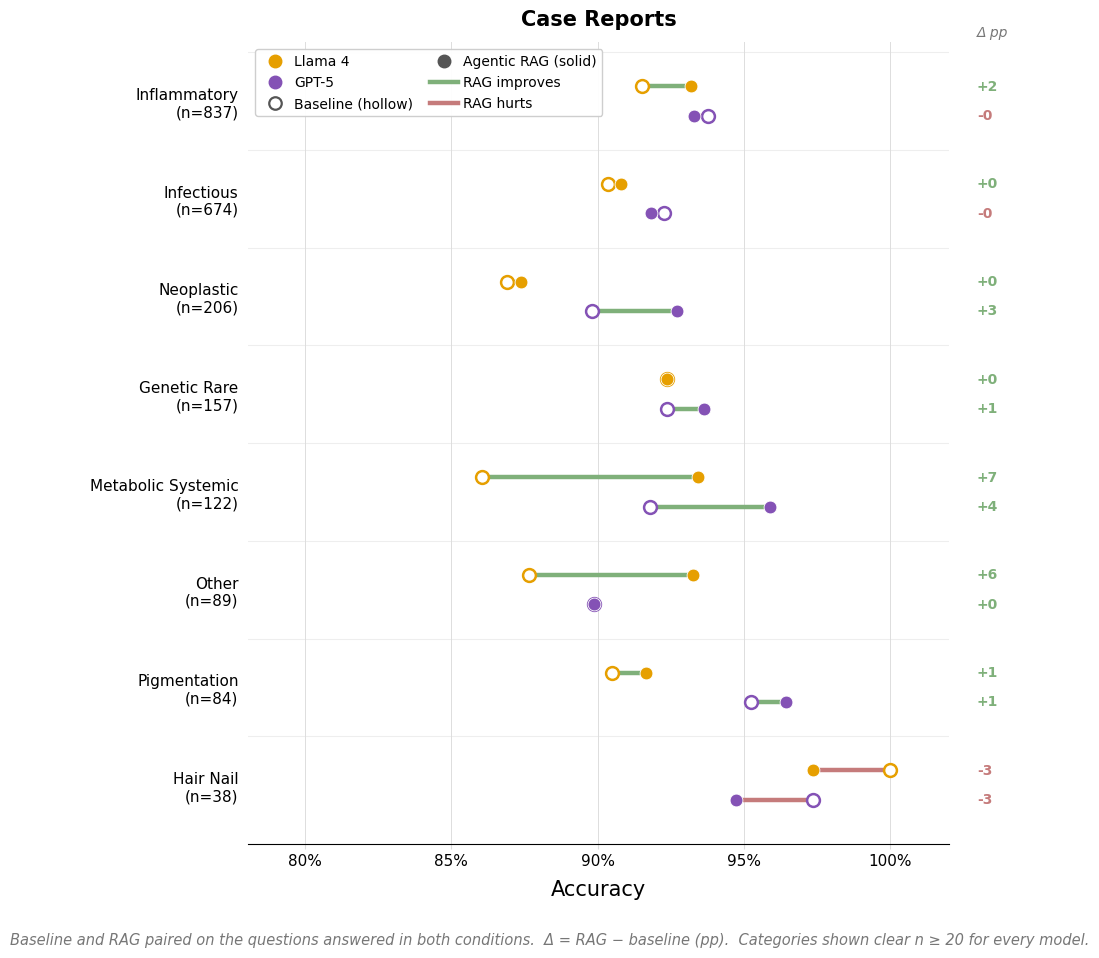

In [24]:
# =========================================================
#  Two-model paired dumbbell: baseline -> agentic RAG by disease category.
#  Overlays a small set of models (2, up to ~3) as offset tracks within each
#  category row. Reuses paired_accuracy_by_category / CATEGORY_ORDER from above.
#    dot color   = model      (contrasting palette, so the two models pop apart)
#    dot fill    = condition   (hollow = baseline, solid = agentic RAG)
#    line color  = direction   (green = RAG improves, red = RAG hurts)
#  Beyond ~3 models the rows collapse; use plot_category_dumbbell_grid instead.
# =========================================================
DUMBBELL_MODELS = ["llama4", "gpt5"]                    # 2 headline models to overlay (max ~3)
_MODEL_COLORS   = ["#E69F00", "#8452B5", "#56B4E9"]     # per model, contrasting & CB-distinguishable


def _multi_dumbbell_legend_handles(models, colors):
    """Three channels: dot color = model, dot fill = condition, line color = direction."""
    mod = [plt.Line2D([], [], marker="o", ls="", ms=9, color=colors[k],
                      label=models_config[m]) for k, m in enumerate(models)]
    cond = [plt.Line2D([], [], marker="o", ls="", ms=9, markerfacecolor="white",
                       markeredgecolor="#555555", markeredgewidth=1.6, color="#555555",
                       label="Baseline (hollow)"),
            plt.Line2D([], [], marker="o", ls="", ms=9, color="#555555",
                       label="Agentic RAG (solid)")]
    direction = [plt.Line2D([], [], color=UP_COLOR,   lw=3.2, label="RAG improves"),
                 plt.Line2D([], [], color=DOWN_COLOR, lw=3.2, label="RAG hurts")]
    return mod + cond + direction


def plot_category_dumbbell_multi(dataset, models, min_n=MIN_N, save_path=None):
    """Overlaid baseline->RAG dumbbell for a few models, one track per model per category.

    Categories are kept only where EVERY model clears min_n paired questions, so all
    tracks in a row rest on comparable samples. Endpoint % labels are dropped (two
    tracks per row would crowd them); the axis and the per-track Δ gutter carry values.
    Returns {model: paired-accuracy table}.
    """
    M = len(models)
    assert 2 <= M <= 3, "designed for 2-3 models; use plot_category_dumbbell_grid for more"
    colors = _MODEL_COLORS[:M]

    tbls = {m: paired_accuracy_by_category(dataset, m, min_n=0) for m in models}
    shared = [c for c in CATEGORY_ORDER
              if all(c in tbls[m].index and tbls[m].loc[c, "n"] >= min_n for m in models)]
    if not shared:
        raise ValueError(f"no disease category clears min_n={min_n} for all of {models}")
    tbls = {m: tbls[m].reindex(shared) for m in models}
    n_min = pd.concat([tbls[m]["n"].rename(m) for m in models], axis=1).min(axis=1)  # per category

    ncat = len(shared)
    ycat = np.arange(ncat)[::-1]                           # first category on top
    gap = min(0.30, 0.70 / M)                              # spacing between model tracks
    offsets = [((M - 1) / 2 - k) * gap for k in range(M)]  # model 0 on the upper track

    fig, ax = plt.subplots(figsize=(9.5, 0.90 * ncat + 2))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")

    all_vals = []
    for k, m in enumerate(models):
        tbl = tbls[m]
        col = colors[k]
        yy = ycat + offsets[k]
        for yi, (_, row) in zip(yy, tbl.iterrows()):       # connector: green up / red down = direction
            up = row["rag"] >= row["baseline"]
            ax.plot([row["baseline"], row["rag"]], [yi, yi],
                    color=(UP_COLOR if up else DOWN_COLOR), lw=3.2, zorder=2,
                    solid_capstyle="round")
        # baseline = hollow, RAG = solid; colour separates the two models.
        ax.scatter(tbl["baseline"], yy, s=85, facecolors="white", edgecolors=col,
                   linewidths=1.8, zorder=3)
        ax.scatter(tbl["rag"], yy, s=85, facecolors=col, edgecolors="white",
                   linewidths=0.6, zorder=4)
        all_vals += list(tbl["baseline"]) + list(tbl["rag"])

    # Per-track RAG-baseline delta in a right gutter (x in axes fraction, y in data).
    trans = ax.get_yaxis_transform()
    for k, m in enumerate(models):
        for yi, d in zip(ycat + offsets[k], tbls[m]["delta_pp"]):
            ax.text(1.04, yi, f"{d:+.0f}", transform=trans, ha="left", va="center",
                    fontsize=10, fontweight="bold",
                    color=(UP_COLOR if d >= 0 else DOWN_COLOR))
    ax.text(1.04, ncat - 0.3, "Δ pp", transform=trans, ha="left", va="center",
            fontsize=10, style="italic", color="#777777")

    # Faint separators between category groups.
    for yb in np.arange(0.5, ncat - 0.5 + 1e-6, 1.0):
        ax.axhline(yb, color="#EEEEEE", lw=0.8, zorder=0)

    ax.set_yticks(ycat)                                    # one label per category, centred on the pair
    ax.set_yticklabels([f"{c}\n(n={int(n_min[c]):,})" for c in shared], fontsize=11)
    lo = max(0.0, float(min(all_vals)) - 0.08)
    hi = min(1.02, float(max(all_vals)) + 0.05)
    ax.set_xlim(lo, hi)
    ax.set_ylim(-0.6, ncat - 0.4)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color="#DDDDDD", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", left=False)
    ax.tick_params(axis="x", labelsize=11, color="#DDDDDD")
    ax.set_xlabel("Accuracy", fontsize=15, labelpad=8)
    ax.set_title(f"Case Reports",
                 fontsize=15, fontweight="bold", pad=12)
    ax.legend(handles=_multi_dumbbell_legend_handles(models, colors), fontsize=10,
              loc="upper left", frameon=True, framealpha=0.95, edgecolor="#CCCCCC",
              handletextpad=0.4, ncol=2, columnspacing=1.2)

    note = ("Baseline and RAG paired on the questions answered in both conditions.  "
            f"Δ = RAG − baseline (pp).  Categories shown clear n ≥ {min_n} for every model.")
    fig.text(0.5, -0.02, note, ha="center", va="top",
             fontsize=10.5, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return {m: tbls[m] for m in models}


print(f"[dumbbell-multi] {DUMBBELL_DATASET} / {DUMBBELL_MODELS}")
_tbls_multi = plot_category_dumbbell_multi(
    DUMBBELL_DATASET, DUMBBELL_MODELS,
    save_path=(f"../plots/accuracy_benchmarks/dumbbell_category_{DUMBBELL_DATASET}_"
               f"{'_'.join(DUMBBELL_MODELS)}.png"),
)


[dumbbell-facets] medqa / ['llama4', 'gpt5']


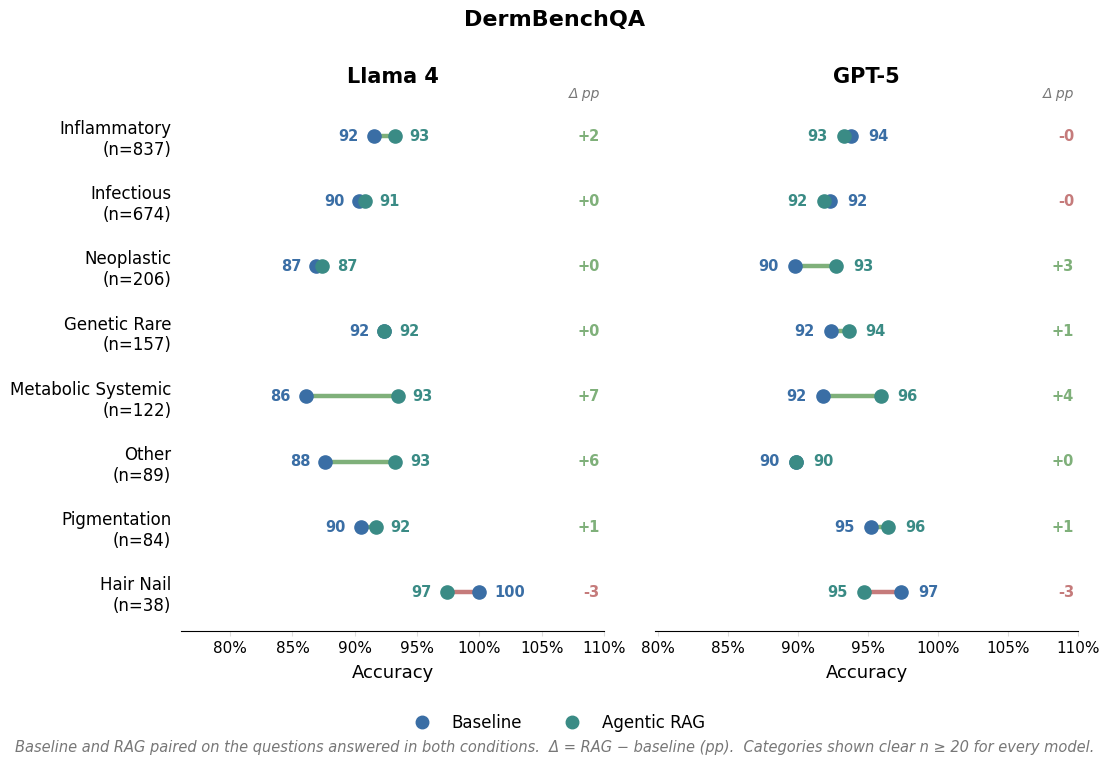

In [25]:
# =========================================================
#  Side-by-side alternative to plot_category_dumbbell_multi: one panel per model,
#  shared category rows. `share_x` controls the horizontal scale:
#    share_x=True  -> one GLOBAL x-range across panels; absolute positions and bar
#                     LENGTHS are directly comparable, but a model in a tight/high
#                     band (e.g. GPT-5) leaves the rest of the range empty.
#    share_x=False -> each panel zooms to its own data; fills the space and makes
#                     small deltas visible, BUT equal pixel-length != equal pp, so
#                     read magnitudes off the Δ gutter, not the connector length.
#  Colour = condition (blue baseline / teal RAG); green/red connector = direction.
#  The Δ column is drawn INSIDE each panel (right margin) so it reads as belonging
#  to that panel, not floating in the gap between them. Reuses _dumbbell_on_ax with
#  show_delta=False so the single-model hero plot keeps its outer gutter.
# =========================================================
DATASET_LABELS = {"pubmed": "DermCaseQA", "medqa": "DermBenchQA"}  # display names for titles


def _panel_delta_column(ax, tbl):
    """Draw the RAG-baseline Δ (pp) inside `ax`, right-aligned in its own right margin."""
    trans = ax.get_yaxis_transform()          # x in axes fraction, y in data coords
    y = np.arange(len(tbl))[::-1]             # first category on top, matching _dumbbell_on_ax
    for yi, d in zip(y, tbl["delta_pp"]):
        ax.text(0.99, yi, f"{d:+.0f}", transform=trans, ha="right", va="center",
                fontsize=10.5, fontweight="bold",
                color=(UP_COLOR if d >= 0 else DOWN_COLOR), zorder=5)
    ax.text(0.99, len(tbl) - 0.35, "Δ pp", transform=trans, ha="right", va="center",
            fontsize=10, style="italic", color="#777777", zorder=5)


def plot_category_dumbbell_facets(dataset, models, min_n=MIN_N, share_x=True, save_path=None):
    """Faceted baseline->RAG dumbbell: one model per panel.

    Categories kept only where EVERY model clears min_n, so panels share identical
    rows. With share_x a single x-range spans all panels (fixes the clipping you get
    from sharex with independent per-panel limits); without it each panel is scaled
    to its own data. Returns {model: paired-accuracy table}.
    """
    tbls = {m: paired_accuracy_by_category(dataset, m, min_n=0) for m in models}
    shared = [c for c in CATEGORY_ORDER
              if all(c in tbls[m].index and tbls[m].loc[c, "n"] >= min_n for m in models)]
    if not shared:
        raise ValueError(f"no disease category clears min_n={min_n} for all of {models}")
    tbls = {m: tbls[m].reindex(shared) for m in models}
    ncat = len(shared)

    # Extra right headroom so the in-panel Δ column clears the endpoint % labels.
    def _xlim(vals):
        return max(0.0, float(min(vals)) - 0.10), min(1.10, float(max(vals)) + 0.18)

    if share_x:
        g_lo, g_hi = _xlim([v for m in models for c in ("baseline", "rag") for v in tbls[m][c]])

    # NB: sharey would let the 2nd panel's empty y-labels wipe the 1st panel's;
    # both panels use identical rows/ylim anyway, so they align without sharing.
    fig, axes = plt.subplots(1, len(models), squeeze=False,
                             figsize=(5.6 * len(models), 0.62 * ncat + 2.2))
    axes = axes[0]
    fig.patch.set_facecolor("white")
    for k, (ax, m) in enumerate(zip(axes, models)):
        ax.set_facecolor("white")
        _dumbbell_on_ax(ax, tbls[m], show_values=True, show_ylabels=(k == 0), show_delta=False)
        if share_x:
            ax.set_xlim(g_lo, g_hi)                      # one common scale
        else:
            ax.set_xlim(*_xlim(list(tbls[m]["baseline"]) + list(tbls[m]["rag"])))  # per-panel zoom
        ax.xaxis.grid(False)                             # no vertical gridlines in this figure
        _panel_delta_column(ax, tbls[m])                 # Δ inside this panel's right margin
        ax.set_title(models_config[m], fontsize=15, fontweight="bold", pad=10)
        ax.set_xlabel("Accuracy", fontsize=13, labelpad=6)

    fig.legend(handles=_dumbbell_legend_handles(), loc="lower center", ncol=2, fontsize=12,
               frameon=False, bbox_to_anchor=(0.5, -0.03))
    ds_label = DATASET_LABELS.get(dataset, dataset.upper())
    fig.suptitle(ds_label, fontsize=16, fontweight="bold", y=1.0)
    note = ("Baseline and RAG paired on the questions answered in both conditions.  "
            f"Δ = RAG − baseline (pp).  Categories shown clear n ≥ {min_n} for every model.")
    fig.text(0.5, -0.02, note, ha="center", va="top",
             fontsize=10.5, style="italic", color="#777777")
    fig.tight_layout(rect=(0, 0.04, 1, 0.99))
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return {m: tbls[m] for m in models}


# share_x=False -> each panel fills its own range; set share_x=True for a common,
# directly-comparable scale (bar lengths comparable, but GPT-5's band leaves space).
print(f"[dumbbell-facets] {DUMBBELL_DATASET} / {DUMBBELL_MODELS}")
_tbls_facets = plot_category_dumbbell_facets(
    DUMBBELL_DATASET, DUMBBELL_MODELS, share_x=False,
    save_path=(f"../plots/accuracy_benchmarks/dumbbell_category_{DUMBBELL_DATASET}_"
               f"{'_'.join(DUMBBELL_MODELS)}_facets.png"),
)


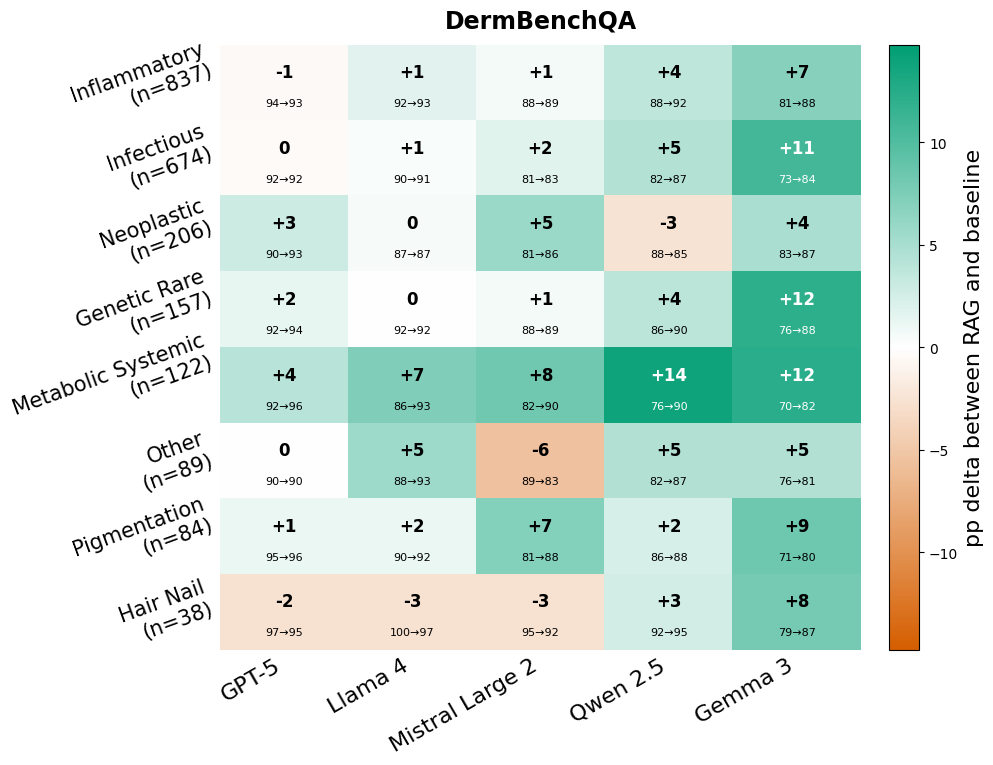

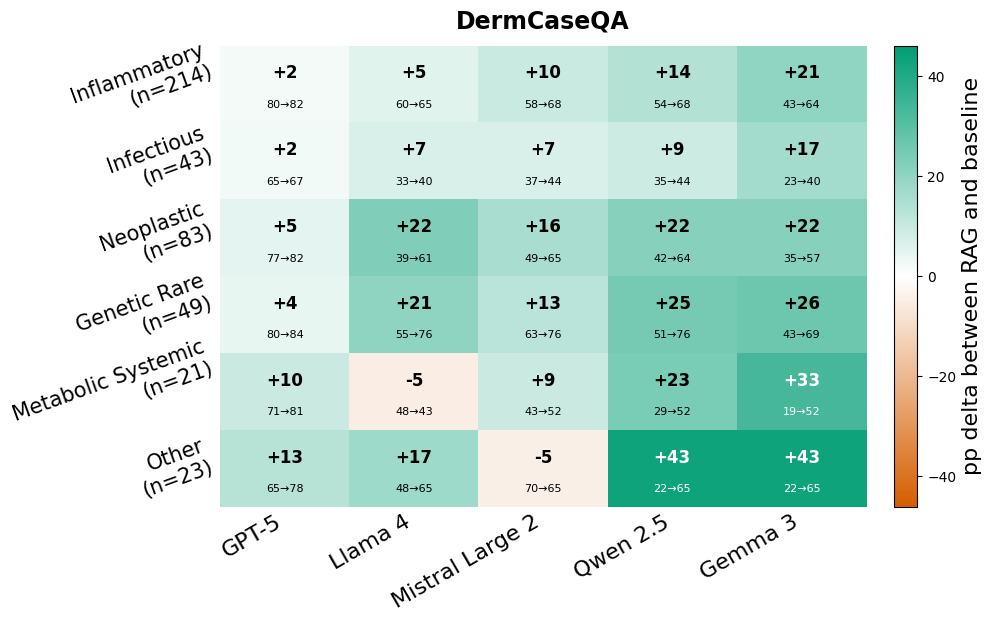

In [26]:
# =========================================================
#  RAG - baseline by disease category  (PRIMARY: subgroup robustness check)
#  Diverging heatmap centred at 0. Each model is compared on the question_ids it
#  answered in BOTH conditions, so the per-category delta is paired.
#  Big number/colour = delta (pp); small number = baseline%→rag% on that paired set.
# =========================================================

from matplotlib.colors import LinearSegmentedColormap


def delta_by_category(dataset):
    """Return (delta, baseline_acc, rag_acc [category x model], smallest paired n).

    delta is in pp; baseline_acc / rag_acc are in % on the SAME paired questions
    the delta is built from, so rag_acc - baseline_acc == delta. Rows follow the
    shared CATEGORY_ORDER; categories with paired n < MIN_N are dropped.
    """
    cats = pd.read_csv(CATEGORY_FILES[dataset])[["question_id", "disease_category"]]
    deltas, base, ragm, counts = {}, {}, {}, []
    for model in models_by_dataset[dataset]:
        b = dfs_by_dataset[dataset][(model, "baseline")].set_index("question_id")["is_correct"]
        r = dfs_by_dataset[dataset][(model, "rag")].set_index("question_id")["is_correct"]
        shared = b.index.intersection(r.index)
        d = (pd.DataFrame({"baseline": b.loc[shared], "rag": r.loc[shared]})
               .reset_index().merge(cats, on="question_id"))
        g = d.groupby("disease_category")
        name = models_config[model]
        base[name]   = g["baseline"].mean() * 100                      # %
        ragm[name]   = g["rag"].mean() * 100                           # %
        deltas[name] = ragm[name] - base[name]                         # pp
        counts.append(g.size().rename(name))
    cols = [models_config[m] for m in models_by_dataset[dataset]]
    delta    = pd.DataFrame(deltas)[cols]
    base_acc = pd.DataFrame(base)[cols]
    rag_acc  = pd.DataFrame(ragm)[cols]
    n = pd.concat(counts, axis=1).min(axis=1)  # smallest paired n across models, per category
    order = [c for c in CATEGORY_ORDER if c in delta.index and n.get(c, 0) >= MIN_N]
    return delta.loc[order], base_acc.loc[order], rag_acc.loc[order], n.loc[order]


def _annotate_delta_cells(ax, delta, base_acc, rag_acc, cmap, norm):
    """Big coloured delta per cell, with a small baseline%→rag% line beneath it."""
    for i in range(delta.shape[0]):
        for j in range(delta.shape[1]):
            v = delta.values[i, j]
            if pd.isna(v):
                continue
            col = _text_color(cmap, float(norm(v)))
            b, r = base_acc.values[i, j], rag_acc.values[i, j]
            paired = pd.notna(b) and pd.notna(r)
            # big number = delta of the ROUNDED endpoints, so it always equals
            # (right - left) of the small number (avoids 0 shown over e.g. 94->93)
            big = (round(r) - round(b)) if paired else v
            ax.text(j, i - 0.14, _pp(big), ha="center", va="center",
                    fontsize=12, fontweight="bold", color=col)
            if paired:
                ax.text(j, i + 0.27, f"{b:.0f}→{r:.0f}", ha="center", va="center",
                        fontsize=8, color=col)


def plot_category_delta_heatmap(dataset, save_path=None):
    delta, base_acc, rag_acc, n = delta_by_category(dataset)
    norm = _delta_norm(delta.values)  # symmetric limits just past the largest |delta|
    # plum = RAG hurts (negative), teal = RAG helps (positive)
    # light-grey midpoint so zero-delta cells stay visible on the white figure

    cmap = LinearSegmentedColormap.from_list(
    "delta_GnVe", ["#D55E00", "#FFFFFF", "#009E73"])

    fig, ax = plt.subplots(figsize=(1.3 * len(delta.columns) + 3.5, 0.72 * len(delta) + 2))
    fig.patch.set_facecolor("white")
    im = ax.imshow(delta.values, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(delta.columns)))
    ax.set_xticklabels(delta.columns, rotation=30, ha="right", fontsize=16)
    ax.set_yticks(range(len(delta.index)))
    ax.set_yticklabels(_ylabels(n), fontsize=15, rotation=20, va="center")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    _annotate_delta_cells(ax, delta, base_acc, rag_acc, cmap, norm)
    _flag_low_n_rows(ax, n, delta.shape[1])

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("pp delta between RAG and baseline", fontsize=16)
    # tick each side of 0 independently so the smaller negative side still gets labels
    _loc = mticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10])
    _neg = [t for t in _loc.tick_values(norm.vmin, 0) if norm.vmin <= t < 0]
    _pos = [t for t in _loc.tick_values(0, norm.vmax) if 0 <= t <= norm.vmax]
    cbar.set_ticks(sorted(set(_neg + _pos)))
    ax.set_title(DATASET_TITLES[dataset],
                 fontsize=17, fontweight="bold", pad=12)
    footnote = ("Big number/colour: RAG - baseline (pp).  "
                f"Small number: baseline%→RAG% on the paired questions.  "
                "Teal = RAG helps, plum = RAG hurts.")
    if (n < LOW_N).any():
        footnote += f"\n* hatched: n < {LOW_N}; per-category delta is unreliable."
    #fig.text(0.5, -0.03, footnote, ha="center", va="top",
    #         fontsize=11, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return delta


for ds in DATASETS:
    plot_category_delta_heatmap(
        ds, save_path=f"../plots/accuracy_benchmarks/rag_effect_by_category_{ds}.png",
    )

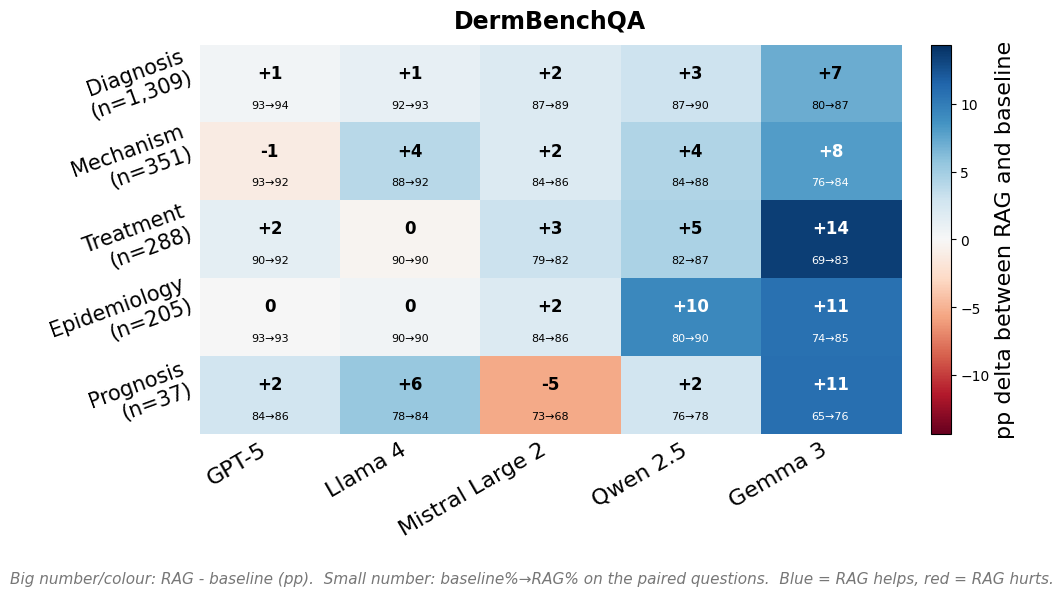

,GPT-5,Llama 4,Mistral Large 2,Qwen 2.5,Gemma 3
question_type,,,,,
diagnosis,0.381971,1.145913,1.909855,2.979374,7.104660
mechanism,-1.139601,3.988604,1.994302,4.273504,7.977208
treatment,1.388889,-0.347222,3.125000,4.513889,13.541667
epidemiology,0.000000,0.487805,1.951220,9.268293,10.731707
prognosis,2.702703,5.405405,-5.405405,2.702703,10.810811


In [27]:
# =========================================================
#  RAG - baseline by MedQA question type  (companion to the disease-category view)
#  Same paired construction as delta_by_category: each model is compared on the
#  question_ids it answered in BOTH conditions, so the per-type delta is paired.
#  Big number/colour = delta (pp); small number = baseline%→rag% on that paired set.
#  question_type is a MedQA category field, so this is MedQA only.
# =========================================================
def delta_by_qtype(dataset):
    """Return (delta, baseline_acc, rag_acc [question_type x model], smallest paired n)."""
    cats = pd.read_csv(CATEGORY_FILES[dataset])[["question_id", "question_type"]]
    qt_order = list(cats["question_type"].value_counts().index)  # most common first
    deltas, base, ragm, counts = {}, {}, {}, []
    for model in models_by_dataset[dataset]:
        b = dfs_by_dataset[dataset][(model, "baseline")].set_index("question_id")["is_correct"]
        r = dfs_by_dataset[dataset][(model, "rag")].set_index("question_id")["is_correct"]
        shared = b.index.intersection(r.index)
        d = (pd.DataFrame({"baseline": b.loc[shared], "rag": r.loc[shared]})
               .reset_index().merge(cats, on="question_id"))
        g = d.groupby("question_type")
        name = models_config[model]
        base[name]   = g["baseline"].mean() * 100                      # %
        ragm[name]   = g["rag"].mean() * 100                           # %
        deltas[name] = ragm[name] - base[name]                         # pp
        counts.append(g.size().rename(name))
    cols = [models_config[m] for m in models_by_dataset[dataset]]
    delta    = pd.DataFrame(deltas)[cols]
    base_acc = pd.DataFrame(base)[cols]
    rag_acc  = pd.DataFrame(ragm)[cols]
    n = pd.concat(counts, axis=1).min(axis=1)  # smallest paired n across models, per type
    order = [c for c in qt_order if c in delta.index and n.get(c, 0) >= MIN_N]
    return delta.loc[order], base_acc.loc[order], rag_acc.loc[order], n.loc[order]


def _qtype_ylabels(n):
    """Row labels 'Question type\n(n=...)', capitalized, asterisked below LOW_N."""
    return [f"{str(c).capitalize()}\n(n={n[c]:,}){' *' if n[c] < LOW_N else ''}" for c in n.index]


def plot_qtype_delta_heatmap(dataset, save_path=None):
    delta, base_acc, rag_acc, n = delta_by_qtype(dataset)
    norm = _delta_norm(delta.values)  # symmetric limits just past the largest |delta|
    cmap = plt.get_cmap("RdBu")

    fig, ax = plt.subplots(figsize=(1.3 * len(delta.columns) + 3.5, 0.72 * len(delta) + 2))
    fig.patch.set_facecolor("white")
    im = ax.imshow(delta.values, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(delta.columns)))
    ax.set_xticklabels(delta.columns, rotation=30, ha="right", fontsize=16)
    ax.set_yticks(range(len(delta.index)))
    ax.set_yticklabels(_qtype_ylabels(n), fontsize=15, rotation=20, va="center")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    _annotate_delta_cells(ax, delta, base_acc, rag_acc, cmap, norm)
    _flag_low_n_rows(ax, n, delta.shape[1])

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("pp delta between RAG and baseline", fontsize=16)
    # tick each side of 0 independently so the smaller negative side still gets labels
    _loc = mticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10])
    _neg = [t for t in _loc.tick_values(norm.vmin, 0) if norm.vmin <= t < 0]
    _pos = [t for t in _loc.tick_values(0, norm.vmax) if 0 <= t <= norm.vmax]
    cbar.set_ticks(sorted(set(_neg + _pos)))
    ax.set_title(DATASET_TITLES[dataset],
                 fontsize=17, fontweight="bold", pad=12)
    footnote = ("Big number/colour: RAG - baseline (pp).  "
                f"Small number: baseline%→RAG% on the paired questions.  "
                "Blue = RAG helps, red = RAG hurts.")
    if (n < LOW_N).any():
        footnote += f"\n* hatched: n < {LOW_N}; per-type delta is unreliable."
    fig.text(0.5, -0.03, footnote, ha="center", va="top",
             fontsize=11, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return delta


qtype_delta = plot_qtype_delta_heatmap(
    "medqa", save_path="../plots/accuracy_benchmarks/rag_effect_by_question_type_medqa.png",
)
qtype_delta

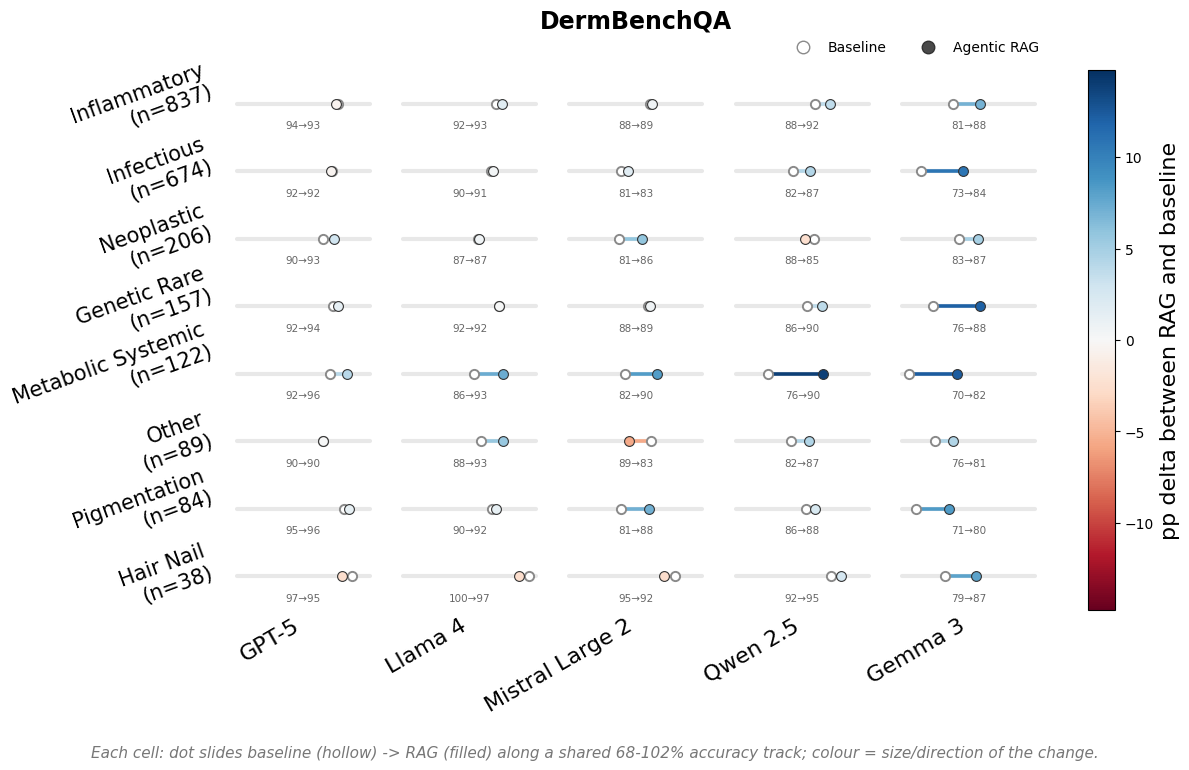

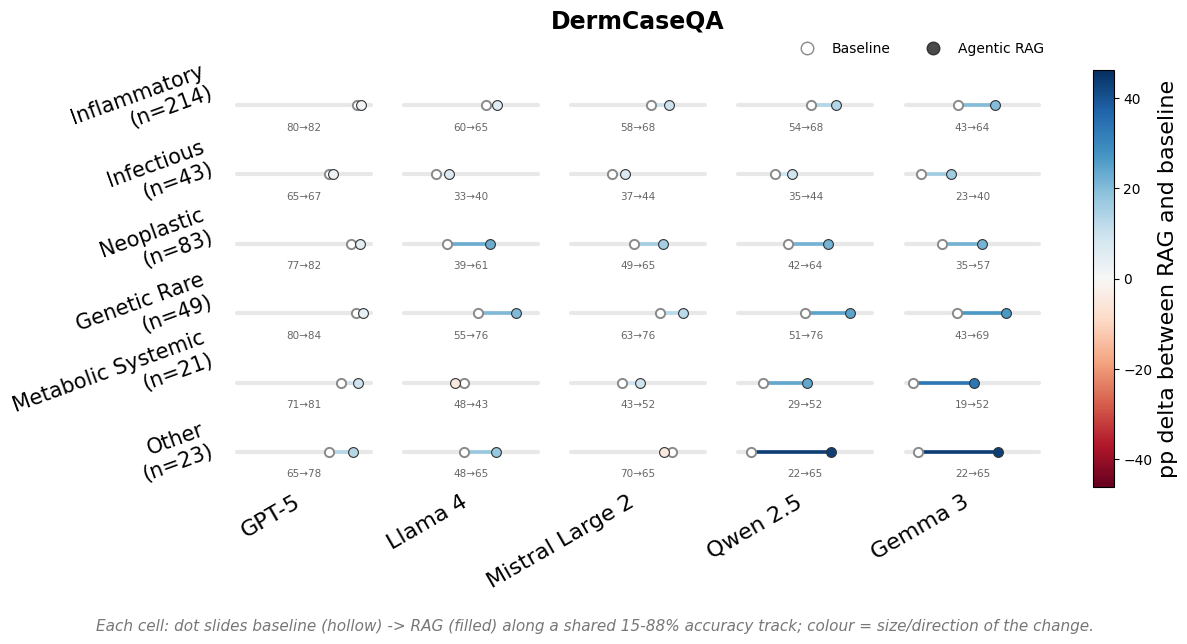

In [28]:
# =========================================================
#  PROTOTYPE (option 4): dumbbell / slope inside each cell
#  Each cell shows a dot sliding from baseline (hollow) to RAG (filled) along a
#  shared accuracy track; the connector's colour = size/direction of the change
#  (RdBu, same as the delta heatmaps). Position conveys absolute accuracy, the
#  segment conveys the effect. Reuses delta_by_category(); existing plots untouched.
# =========================================================
from matplotlib.lines import Line2D


def plot_dumbbell_category(dataset, save_path=None):
    delta, base_acc, rag_acc, n = delta_by_category(dataset)
    cmap = plt.get_cmap("RdBu")
    norm = _delta_norm(delta.values)

    # shared accuracy track range across every cell (a little past the data)
    acc_vals = np.concatenate([base_acc.values.ravel(), rag_acc.values.ravel()])
    acc_vals = acc_vals[~np.isnan(acc_vals)]
    lo, hi = float(acc_vals.min()), float(acc_vals.max())
    pad = 0.06 * max(hi - lo, 1e-9)
    tmin, tmax = lo - pad, hi + pad

    def xpos(acc, j):                      # accuracy% -> x within cell j (half-width 0.4)
        return j - 0.4 + 0.8 * (acc - tmin) / (tmax - tmin)

    ncols, nrows = len(delta.columns), len(delta)
    fig, ax = plt.subplots(figsize=(1.7 * ncols + 3.5, 0.62 * nrows + 2.4))
    fig.patch.set_facecolor("white")

    for i in range(nrows):
        for j in range(ncols):
            b, r, v = base_acc.values[i, j], rag_acc.values[i, j], delta.values[i, j]
            if pd.isna(v):
                continue
            ax.plot([j - 0.4, j + 0.4], [i, i], color="#e8e8e8", lw=3,
                    solid_capstyle="round", zorder=1)          # faint 0-track
            xb, xr = xpos(b, j), xpos(r, j)
            c = cmap(float(norm(v)))
            ax.plot([xb, xr], [i, i], color=c, lw=2.6, solid_capstyle="round", zorder=2)
            ax.scatter([xb], [i], s=44, facecolors="white", edgecolors="#8a8a8a",
                       linewidths=1.4, zorder=3)               # baseline: hollow
            ax.scatter([xr], [i], s=50, facecolors=c, edgecolors="#333333",
                       linewidths=0.8, zorder=4)               # rag: filled
            ax.text(j, i + 0.32, f"{b:.0f}→{r:.0f}", ha="center", va="center",
                    fontsize=7.5, color="#666666", zorder=5)

    ax.set_xlim(-0.5, ncols - 0.5)
    ax.set_ylim(nrows - 0.5, -0.5)                             # row 0 at top
    ax.set_xticks(range(ncols))
    ax.set_xticklabels(delta.columns, rotation=30, ha="right", fontsize=16)
    ax.set_yticks(range(nrows))
    ax.set_yticklabels(_ylabels(n), fontsize=15, rotation=20, va="center")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    _flag_low_n_rows(ax, n, ncols)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("pp delta between RAG and baseline", fontsize=16)
    _loc = mticker.MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10])
    _neg = [t for t in _loc.tick_values(norm.vmin, 0) if norm.vmin <= t < 0]
    _pos = [t for t in _loc.tick_values(0, norm.vmax) if 0 <= t <= norm.vmax]
    cbar.set_ticks(sorted(set(_neg + _pos)))

    handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white",
               markeredgecolor="#8a8a8a", markersize=9, label="Baseline"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#4a4a4a",
               markeredgecolor="#333333", markersize=9, label="Agentic RAG"),
    ]
    ax.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.0, 1.005),
              ncol=2, frameon=False, fontsize=10)

    ax.set_title(DATASET_TITLES[dataset], fontsize=17, fontweight="bold", pad=30)
    footnote = (f"Each cell: dot slides baseline (hollow) -> RAG (filled) along a shared "
                f"{tmin:.0f}-{tmax:.0f}% accuracy track; colour = size/direction of the change.")
    if (n < LOW_N).any():
        footnote += f"\n* hatched: n < {LOW_N}; per-category values are unreliable."
    fig.text(0.5, -0.02, footnote, ha="center", va="top",
             fontsize=11, style="italic", color="#777777")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    return delta


for ds in DATASETS:
    plot_dumbbell_category(
        ds, save_path=f"../plots/accuracy_benchmarks/dumbbell_by_category_{ds}.png",
    )
